Testing things out

In [423]:
"""import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns


data = {
    'apples': [6, 2, 7, 1],
    'oranges': [1, 2, 9, 3]
}

customer_names = ['Alice', 'Bob', 'Charlie', 'David']

df = pd.DataFrame(data)

df.set_index(pd.Index(customer_names), inplace=True)

display(df)

display(df.loc['Bob'])"""

"import numpy as np\nimport pandas as pd\nimport matplotlib.pyplot as plt\nfrom scipy import stats\nimport seaborn as sns\n\n\ndata = {\n    'apples': [6, 2, 7, 1],\n    'oranges': [1, 2, 9, 3]\n}\n\ncustomer_names = ['Alice', 'Bob', 'Charlie', 'David']\n\ndf = pd.DataFrame(data)\n\ndf.set_index(pd.Index(customer_names), inplace=True)\n\ndisplay(df)\n\ndisplay(df.loc['Bob'])"

Task 1: Import the csv and libraries

In [424]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns


url = "https://raw.githubusercontent.com/DAVE3625/Dave3625-Host-2025/refs/heads/main/Lab2/data/stud.csv"

df = pd.read_csv(url, sep=',')

Task 2: Clean the data

In [425]:
display(df.head())

display(df.describe())

display(df.info())










,StudentID,Age,email,hrsStudy,FinalGrade
0,47412,20,s47412@oslomet.no,5,46.0
1,15077,22,s15077@oslomet.no,0,65.0
2,15467,27,s15467@oslomet.no,1,26.0
3,17907,21,s17907@oslomet.no,6,68.0
4,13352,333,s13352@oslomet.no,4,34.0


,StudentID,FinalGrade
count,50.000000,49.000000
mean,48969.820000,71.653061
std,26870.066326,90.455917
min,10736.000000,24.000000
25%,26666.500000,39.000000
50%,44292.000000,60.000000
75%,70400.250000,78.000000
max,99823.000000,673.000000


<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   StudentID   50 non-null     int64  
 1   Age         50 non-null     str    
 2   email       50 non-null     str    
 3   hrsStudy    50 non-null     str    
 4   FinalGrade  49 non-null     float64
dtypes: float64(1), int64(1), str(3)
memory usage: 2.1 KB


None

Age, email and hrsStudy are all strings

In [426]:
display(df.isna().sum())

display(df)



StudentID     0
Age           0
email         0
hrsStudy      0
FinalGrade    1
dtype: int64

,StudentID,Age,email,hrsStudy,FinalGrade
0,47412,20,s47412@oslomet.no,5,46.0
1,15077,22,s15077@oslomet.no,0,65.0
2,15467,27,s15467@oslomet.no,1,26.0
3,17907,21,s17907@oslomet.no,6,68.0
4,13352,333,s13352@oslomet.no,4,34.0
5,88403,29,s88403@oslomet.no,11,62.0
6,56387,32,s56387@oslomet.no,9,29.0
7,95648,23,s95648@oslomet.no,3,38.0
8,63176,20,s63176@oslomet.no,0,98.0
9,15406,31,s15406@oslomet.no,2,68.0


We have empty cells in both hrsStudy and age, lets replace them with np.nan and check again

In [427]:
df=df.replace(r'^\s*$', np.nan, regex=True)

display(df.isna().sum())

StudentID     0
Age           1
email         0
hrsStudy      1
FinalGrade    1
dtype: int64

Now we see that we have missing values in 3 categories. We can fill dummy values in age if its not important

In [428]:
df.replace({'Age': {np.nan: 0}}, inplace=True)

display(df.isna().sum())

StudentID     0
Age           0
email         0
hrsStudy      1
FinalGrade    1
dtype: int64

Now we have "fixed" the age column. Cince the rest of the columns contain important data, we will not fill them with dummy data. isntead we will delete the incomplete rows.

In [429]:
df.dropna(inplace=True)

display(df.isna().sum())

StudentID     0
Age           0
email         0
hrsStudy      0
FinalGrade    0
dtype: int64

Now we want to convert the columns to their correct data types

In [430]:
df['Age'] = df['Age'].astype(str).astype(int)

df['hrsStudy'] = df['hrsStudy'].astype(int)

display(df.info())

display(df.describe())

<class 'pandas.DataFrame'>
Index: 48 entries, 0 to 49
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   StudentID   48 non-null     int64  
 1   Age         48 non-null     int64  
 2   email       48 non-null     str    
 3   hrsStudy    48 non-null     int64  
 4   FinalGrade  48 non-null     float64
dtypes: float64(1), int64(3), str(1)
memory usage: 2.2 KB


None

,StudentID,Age,hrsStudy,FinalGrade
count,48.000000,48.000000,48.000000,48.000000
mean,50338.166667,35.666667,6.395833,72.083333
std,26526.981827,52.388619,3.648022,91.362461
min,11758.000000,0.000000,0.000000,24.000000
25%,28399.750000,22.000000,3.000000,38.750000
50%,45986.500000,25.000000,7.000000,61.000000
75%,71524.000000,31.000000,10.000000,78.500000
max,99823.000000,333.000000,11.000000,673.000000


Task 3: look for outliers in the Final Grade column

<Axes: >

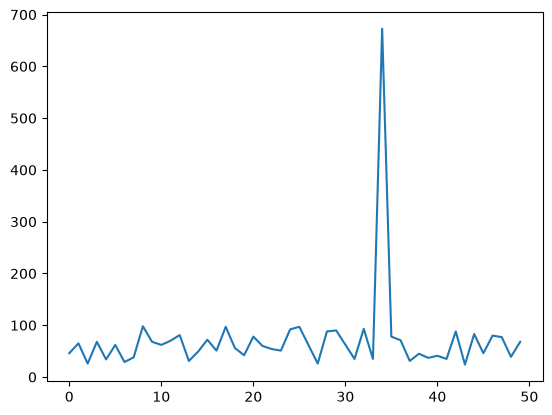

In [431]:
display(df["FinalGrade"].plot.line())

As we can see there is one value wich isclearly wrong. where every other grade is below 100, one of them is almost 700. 

We will calculate the z-score and drop all elements above 3 z-score

<Axes: >

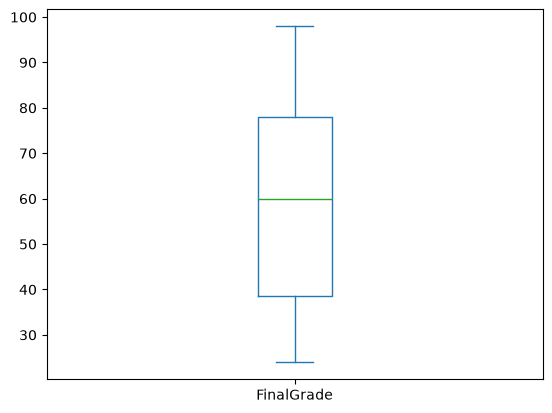

In [432]:
z_scores = stats.zscore(df['FinalGrade'])

abs_z_scores = np.abs(z_scores)

df.drop(df[abs_z_scores > 3].index, inplace=True)

display(df["FinalGrade"].plot.box())

Now that we have removed an outlier, let us look ath the end of or dataframe

In [433]:
display(df.tail())

,StudentID,Age,email,hrsStudy,FinalGrade
45,62039,23,s62039@oslomet.no,4,46.0
46,42989,27,s42989@oslomet.no,0,80.0
47,85370,29,s85370@oslomet.no,2,77.0
48,63135,26,s63135@oslomet.no,9,39.0
49,28895,19,s28895@oslomet.no,10,68.0


We still have 49 entries even after deleting some entries, so let me reset the indexes

In [434]:
df=df.reset_index(drop=True)

display(df.tail())

,StudentID,Age,email,hrsStudy,FinalGrade
42,62039,23,s62039@oslomet.no,4,46.0
43,42989,27,s42989@oslomet.no,0,80.0
44,85370,29,s85370@oslomet.no,2,77.0
45,63135,26,s63135@oslomet.no,9,39.0
46,28895,19,s28895@oslomet.no,10,68.0


Task 4: Add a grade column

In [435]:
conditions = [
    (df['FinalGrade'] <= 50),
    (df['FinalGrade'] > 50) & (df['FinalGrade'] <= 60),
    (df['FinalGrade'] > 60) & (df['FinalGrade'] <= 70),
    (df['FinalGrade'] > 70) & (df['FinalGrade'] <= 80),
    (df['FinalGrade'] > 80) & (df['FinalGrade'] <= 90),
    (df['FinalGrade'] > 90)
]

values = ['F', 'E','D', 'C', 'B', 'A']

df['Grade'] = np.select(conditions, values, default='F')

display(df.head())


,StudentID,Age,email,hrsStudy,FinalGrade,Grade
0,47412,20,s47412@oslomet.no,5,46.0,F
1,15077,22,s15077@oslomet.no,0,65.0,D
2,15467,27,s15467@oslomet.no,1,26.0,F
3,17907,21,s17907@oslomet.no,6,68.0,D
4,13352,333,s13352@oslomet.no,4,34.0,F


Task 5: Group studnets by their grades

Grade
A     5
B     5
C     6
D     7
E     5
F    19
Name: FinalGrade, dtype: int64

<Axes: xlabel='Grade'>

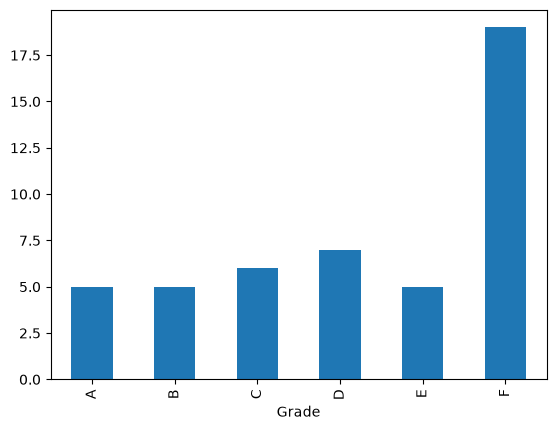

In [436]:
df_gradeCount =df.groupby('Grade').count()

display(df_gradeCount.FinalGrade)

display(df_gradeCount["FinalGrade"].plot.bar())

Let us have a look at another plot

<Axes: xlabel='Age', ylabel='Grade'>

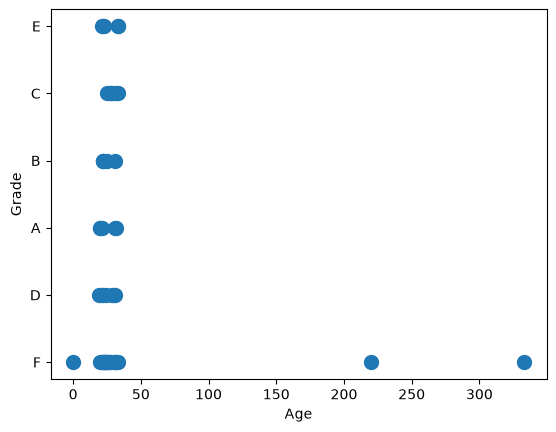

In [437]:
display(df.plot.scatter(x='Age', y = 'Grade', s = 100))

Let me make the plot better by removing the outliers

<Axes: xlabel='Age', ylabel='Grade'>

<Axes: ylabel='Frequency'>

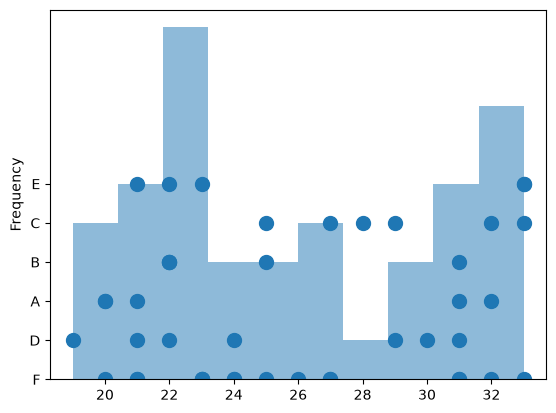

In [438]:
z_scores = stats.zscore(df['Age'])

abs_z_scores = np.abs(z_scores)

df.drop(df[abs_z_scores > 3].index, inplace=True)

df.drop(df[df['Age'] < 18].index, inplace=True)

display(df.plot.scatter( x ='Age', y = 'Grade', s = 100))

display(df["Age"].plot.hist(alpha=0.5))